# NIRSPEC 6927 Candidate Selection

In [33]:
from astropy.table import Table
from astropy.io import fits
from astropy import wcs
import regions
import pylab as pl
from astroquery.svo_fps import SvoFps
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy import coordinates
from dust_extinction.averages import RRP89_MWGC, CT06_MWGC, F11_MWGC

In [75]:
# specially created from intermediate products on 2026-07-14 (2027 was a typo...)
# "final final" products should be later this week, but need this _now_

tb = Table.read('/Users/adam/Dropbox/brick2221/brick_crossband_m7_merge_20260714.fits')
wholebrickreg = regions.Regions.read('/Users/adam//work/brick/jwst/brick-jwst-2221/regions_/dark_innerbrick_polygon.reg')[0]

tb_6927_default = Table.read('/Users/adam/Dropbox/brick2221/nirspec6927/MPT_sourcelist.v17.txt', format='ascii')

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')


# for col in [x for x in tb.colnames if 'flux' in x and 'err' not in x]:
#     pixelscale = (0.031*u.arcsec)**2 if int(col[1:4]) < 250 else (0.063*u.arcsec)**2
#     flux_jy = (tb[col] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     eflux_jy = (tb[col+"_err"] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     filtername = f'JWST/NIRCam.{col[:5].upper()}'
#     zeropoint = u.Quantity(jfilts.loc[filtername]['ZeroPoint'], u.Jy)
#     vegamag = -2.5 * np.log10(flux_jy / zeropoint) * u.mag
#     mag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux_jy) * u.mag
#     tb[f'mag_{col[:5]}'] = vegamag
#     tb[f'mag_{col[:5]}'].meta = {'system': 'Vega mag'}
#     tb[f'emag_{col[:5]}'] = mag_err
#     tb[f'emag_{col[:5]}'].meta = {'system': 'eVega mag'}
basetable = tb

tb['skycoord_ref'] = crd = coordinates.SkyCoord(tb['ra'], tb['dec'], unit=(u.deg, u.deg), frame='icrs')

fh = fits.open('/Users/adam/Dropbox/brick2221/20240802_FITS/jw02221-o001_t001_nircam_clear-f410m-merged_i2d.fits')
ww = wcs.WCS(fh['SCI'].header)


av182410 = (basetable['f182m_mag_vega'] - basetable['f410m_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(4.10*u.um))
av182212 = (basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(2.12*u.um))

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


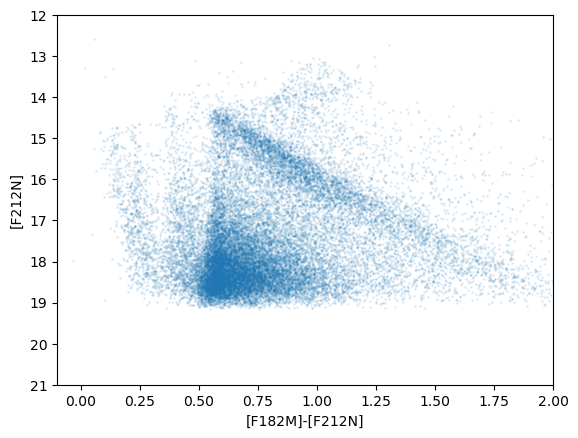

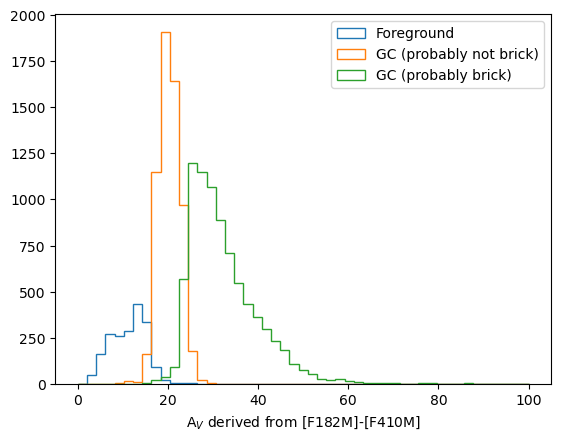

In [77]:
notbad = (
          (basetable['f212n_emag_vega'] < 0.1) &
          (basetable['f410m_emag_vega'] < 0.1) &
          (basetable['f182m_emag_vega'] < 0.1) &
          (basetable['f212n_nmatch_good'] > 4) &
          (basetable['f182m_nmatch_good'] > 4) &
          (basetable['f410m_nmatch_good'] > 4) &
            (basetable['f212n_qfit'] < 0.4) &
            (basetable['f182m_qfit'] < 0.4) &
            (basetable['f410m_qfit'] < 0.4) 
)

bright = ((basetable['f212n_mag_vega'] > 14) &
          (basetable['f212n_mag_vega'] < 18) & notbad)
          

pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[notbad], basetable['f212n_mag_vega'][notbad], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & notbad
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 2, 21, 12]);
pl.xlabel("[F182M]-[F212N]")
pl.ylabel("[F212N]");

pl.figure()
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.5)], bins=np.linspace(0, 100),
        label='Foreground', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.75) & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.5)], bins=np.linspace(0, 100),
        label='GC (probably not brick)', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.75)], bins=np.linspace(0, 100),
        label='GC (probably brick)', histtype='step', density=False);
pl.legend(loc='best');
pl.xlabel("A$_V$ derived from [F182M]-[F410M]");


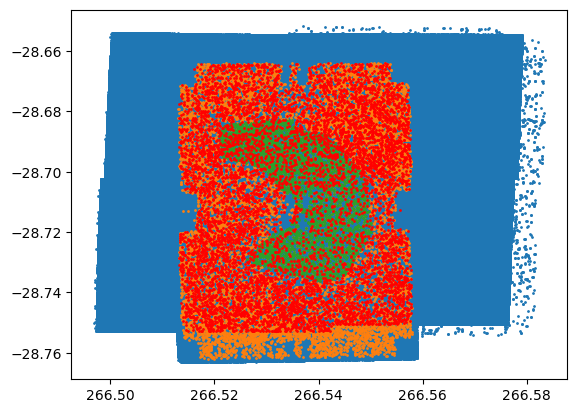

In [114]:
pl.scatter(tb['skycoord_ref'].ra, tb['skycoord_ref'].dec, s=1)
pl.scatter(tb['skycoord_ref'].ra[bright], tb['skycoord_ref'].dec[bright], s=1)
pl.scatter(tb['skycoord_ref'].ra[incl], tb['skycoord_ref'].dec[incl], s=1)
pl.scatter(tb_6927_default['RA'], tb_6927_default['DEC'], s=1, c='r')

### Find mutual matches between 6927-candidate-list-from-2025 and new catalog

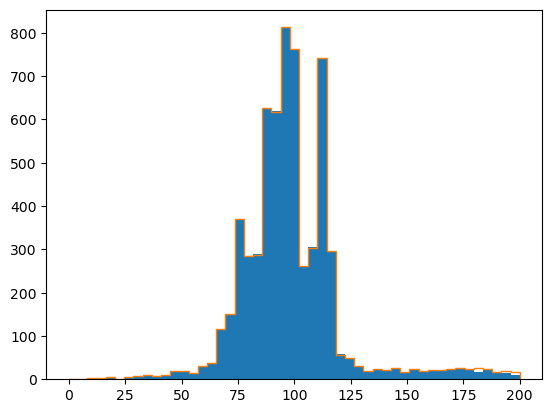

In [118]:
crd6927 = SkyCoord(tb_6927_default['RA'], tb_6927_default['DEC'], unit=(u.deg, u.deg), frame='icrs')
#i1, i2, sep, _ = search_around_sky(crd6927, crd[notbad], 0.4*u.arcsec)
matches, sep, _ = crd6927.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

## re-match them and check that the matches stay the same (100 marcs is big enough to make mismatches possible)

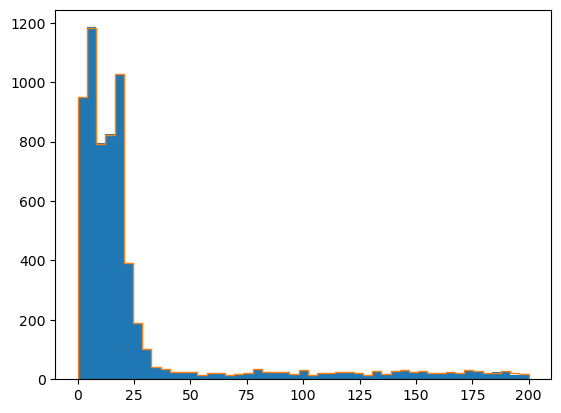

In [119]:
dra_crd = (crd6927.ra - crd[bright].ra[matches]).to(u.deg).value
ddec = (crd6927.dec - crd[bright].dec[matches]).to(u.deg).value
crd6927_fixed = SkyCoord(tb_6927_default['RA'] - np.median(dra_crd), tb_6927_default['DEC'] - np.median(ddec),
                         unit=(u.deg, u.deg), frame='icrs')

matches, sep, _ = crd6927_fixed.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927_fixed, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

In [136]:
tb['WEIGHT'] = 0
tb['WEIGHT'][bright] =  tb_6927_default['WEIGHT'][reverse_matches]

In [139]:
len(tb[bright])

16154

In [141]:
(tb[bright]['f115w_emag_vega'] < 0.1).sum()

np.int64(12488)

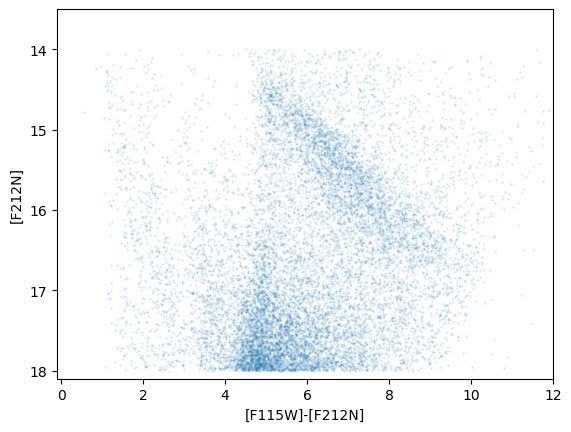

In [146]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 18.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F212N]");

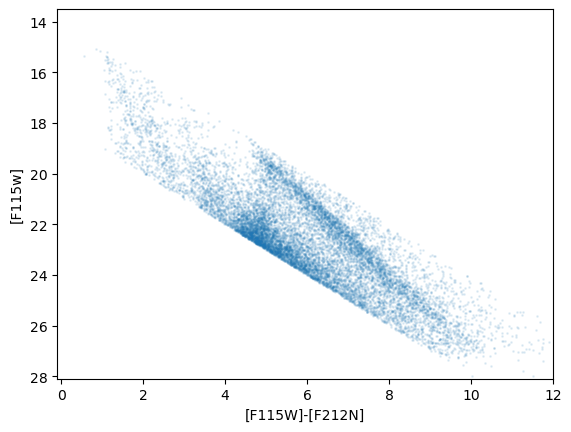

In [149]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f115w_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 28.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F115w]");

In [151]:
tb[bright].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates.fits')